# 🦁🌿🚗 VisioLearn-30 — Transfer Learning Image Classifier
### Real-World Computer Vision | CIFAR-100 | 30 Classes | Google Colab

**Project:** VisioLearn-30 — Visual Intelligence Learning System
**Models:** EfficientNetV2B3 · ResNet50V2 · MobileNetV3Large · ConvNeXtTiny
**Platform:** Google Colab (Runtime → Change runtime type → GPU)

---
### 30 Classes — 11 Groups with Intentional Intra-Group Overlap

| Group | Classes | Overlap Reason |
|-------|---------|----------------|
| 🦁 Big Cats | lion, tiger, leopard | 4-legged predator body |
| 🐘 Large Animals | elephant, camel, bear | large distinct shapes |
| 🐰 Small Rodents | rabbit, mouse, squirrel | small furry round body |
| 🐬 Aquatic | dolphin, whale, shark | streamlined marine body |
| 🦎 Reptiles | snake, lizard, crocodile | scales + crawling |
| 🚌 Road Vehicles | bus, pickup_truck, train | large ground transport |
| 🚲 Two-Wheelers | bicycle, motorcycle | two wheels + rider |
| 🍎 Fruits | apple, orange, pear | round colourful fruit |
| 🌹 Flowers | rose, tulip, sunflower | colourful petals |
| 🏙️ Structures | skyscraper, house | building context |
| 🚀 Distinct | rocket, mushroom | high-accuracy anchors |

## Step 0 — Mount Google Drive & Install Dependencies

In [1]:
# ============================================================
# Setup Kaggle persistent working directory for models + mlruns.
# On Kaggle, files saved in /kaggle/working/ are kept even 
# after the session ends (until you manually clear the output).
# ============================================================

import os

# Project folder on Kaggle's persistent storage
DRIVE_PROJECT = '/kaggle/working/VisioLearn-30'
os.makedirs(DRIVE_PROJECT, exist_ok=True)
os.makedirs(f'{DRIVE_PROJECT}/models', exist_ok=True)
os.makedirs(f'{DRIVE_PROJECT}/mlruns', exist_ok=True)
print(f"Kaggle working folder ready: {DRIVE_PROJECT}")

# Install gradio, mlflow and huggingface_hub
!pip install -q gradio mlflow huggingface_hub

print('All dependencies installed.')

Kaggle working folder ready: /kaggle/working/VisioLearn-30
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 785.3 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 87.4 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 91.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Step 1 — Import Libraries

In [2]:
# ---------------------------------------------------------
# INSTALL MISSING LIBRARY (MLFLOW)
# ---------------------------------------------------------
!pip install -q mlflow

print("MLflow installed successfully!")

MLflow installed successfully!


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import (
    EfficientNetV2B3, ResNet50V2, MobileNetV3Large, ConvNeXtTiny
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
import gradio as gr
import mlflow
import json, random, time, urllib.error, shutil
import keras.saving as keras_saving

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Project: VisioLearn-30")

2026-06-20 11:57:17.669712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781956637.866239      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781956637.923244      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781956638.423844      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781956638.423898      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781956638.423901      58 computation_placer.cc:177] computation placer alr

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Project: VisioLearn-30


## Step 2 — Define 30 Classes & Configuration

In [4]:
# ============================================================
# 30 CIFAR-100 classes in 11 semantic groups.
# Each group has 2-3 overlapping classes by design.
# ============================================================

CIFAR100_CLASSES = [
    'apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle',
    'bicycle','bottle','bowl','boy','bridge','bus','butterfly','camel',
    'can','castle','caterpillar','cattle','chair','chimpanzee','clock',
    'cloud','cockroach','couch','crab','crocodile','cup','dinosaur',
    'dolphin','elephant','flatfish','forest','fox','girl','hamster',
    'house','kangaroo','keyboard','lamp','lawn_mower','leopard','lion',
    'lizard','lobster','man','maple_tree','motorcycle','mountain','mouse',
    'mushroom','oak_tree','orange','orchid','otter','palm_tree','pear',
    'pickup_truck','pine_tree','plain','plate','poppy','porcupine',
    'possum','rabbit','raccoon','ray','road','rocket','rose','sea',
    'seal','shark','shrew','skunk','skyscraper','snail','snake','spider',
    'squirrel','streetcar','sunflower','sweet_pepper','table','tank',
    'telephone','television','tiger','tractor','train','trout','tulip',
    'turtle','wardrobe','whale','willow_tree','wolf','woman','worm'
]

SELECTED_CLASSES = [
    'lion','tiger','leopard',          # Big Cats (overlap)
    'elephant','camel','bear',         # Large Animals
    'rabbit','mouse','squirrel',       # Small Rodents (overlap)
    'dolphin','whale','shark',         # Aquatic (overlap)
    'snake','lizard','crocodile',      # Reptiles (overlap)
    'bus','pickup_truck','train',      # Road Vehicles (overlap)
    'bicycle','motorcycle',            # Two-Wheelers (overlap)
    'apple','orange','pear',           # Fruits (overlap)
    'rose','tulip','sunflower',        # Flowers (overlap)
    'skyscraper','house',              # Structures (overlap)
    'rocket','mushroom',               # Distinct (high accuracy)
]

NUM_CLASSES      = len(SELECTED_CLASSES)  # 30
SELECTED_INDICES = [CIFAR100_CLASSES.index(c) for c in SELECTED_CLASSES]
old_to_new       = {old:new for new,old in enumerate(SELECTED_INDICES)}

IMG_SIZE   = 128
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 0.001

# MLflow experiment name
EXPERIMENT_NAME = 'VisioLearn-30'

print(f"Total classes: {NUM_CLASSES}")
print(f"Classes: {SELECTED_CLASSES}")

Total classes: 30
Classes: ['lion', 'tiger', 'leopard', 'elephant', 'camel', 'bear', 'rabbit', 'mouse', 'squirrel', 'dolphin', 'whale', 'shark', 'snake', 'lizard', 'crocodile', 'bus', 'pickup_truck', 'train', 'bicycle', 'motorcycle', 'apple', 'orange', 'pear', 'rose', 'tulip', 'sunflower', 'skyscraper', 'house', 'rocket', 'mushroom']


## Step 3 — Load & Filter CIFAR-100 Dataset

In [5]:
# ============================================================
# Download CIFAR-100 via Hugging Face (fast CDN) but return 
# it in the exact same format as keras.datasets so the rest 
# of the code doesn't need any changes.
# Filter to our 30 classes and remap labels to 0-29.
# ============================================================

# Install fast downloader
!pip install -q datasets
from datasets import load_dataset

def load_cifar100():
    print("Downloading CIFAR-100 via Hugging Face (fast CDN)...")
    hf_dataset = load_dataset("uoft-cs/cifar100")
    print("Download complete. Converting to Keras format...")
    
    # Convert HF format to EXACT Keras format (so rest of the code works perfectly)
    x_tr = np.array([np.array(img) for img in hf_dataset["train"]["img"]])
    y_tr = np.array(hf_dataset["train"]["fine_label"]).reshape(-1, 1) # Shape (N, 1) like Keras
    x_te = np.array([np.array(img) for img in hf_dataset["test"]["img"]])
    y_te = np.array(hf_dataset["test"]["fine_label"]).reshape(-1, 1)
    
    return (x_tr, y_tr), (x_te, y_te)

# Load data using the fast method
(x_tr_f, y_tr_f), (x_te_f, y_te_f) = load_cifar100()
y_tr_f = y_tr_f.flatten(); y_te_f = y_te_f.flatten()
print(f"Full — train: {x_tr_f.shape}, test: {x_te_f.shape}")

def filter_remap(x, y):
    mask = np.isin(y, SELECTED_INDICES)
    return x[mask], np.array([old_to_new[l] for l in y[mask]])

x_train_raw, y_train = filter_remap(x_tr_f, y_tr_f)
x_test_raw,  y_test  = filter_remap(x_te_f, y_te_f)
print(f"Filtered — train: {x_train_raw.shape[0]}, test: {x_test_raw.shape[0]}")
assert y_train.max() == NUM_CLASSES-1
print("Label mapping OK")

README.md: 0.00B [00:00, ?B/s]

cifar100/train-00000-of-00001.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

cifar100/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Download complete. Converting to Keras format...
Full — train: (50000, 32, 32, 3), test: (10000, 32, 32, 3)
Filtered — train: 15000, test: 3000
Label mapping OK


## Step 3b — Exploratory Data Analysis

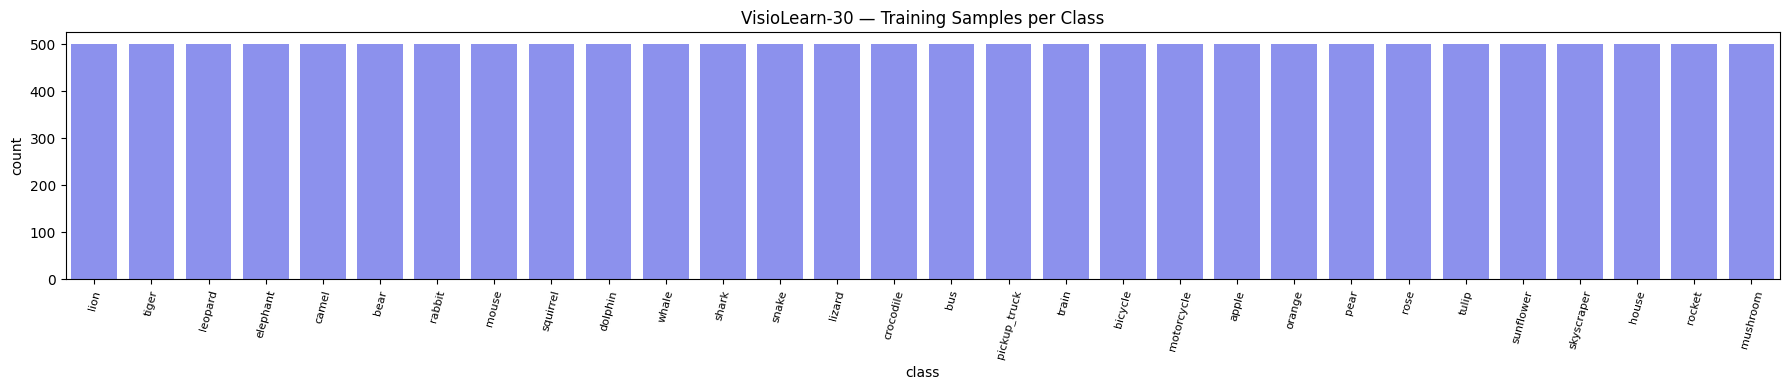

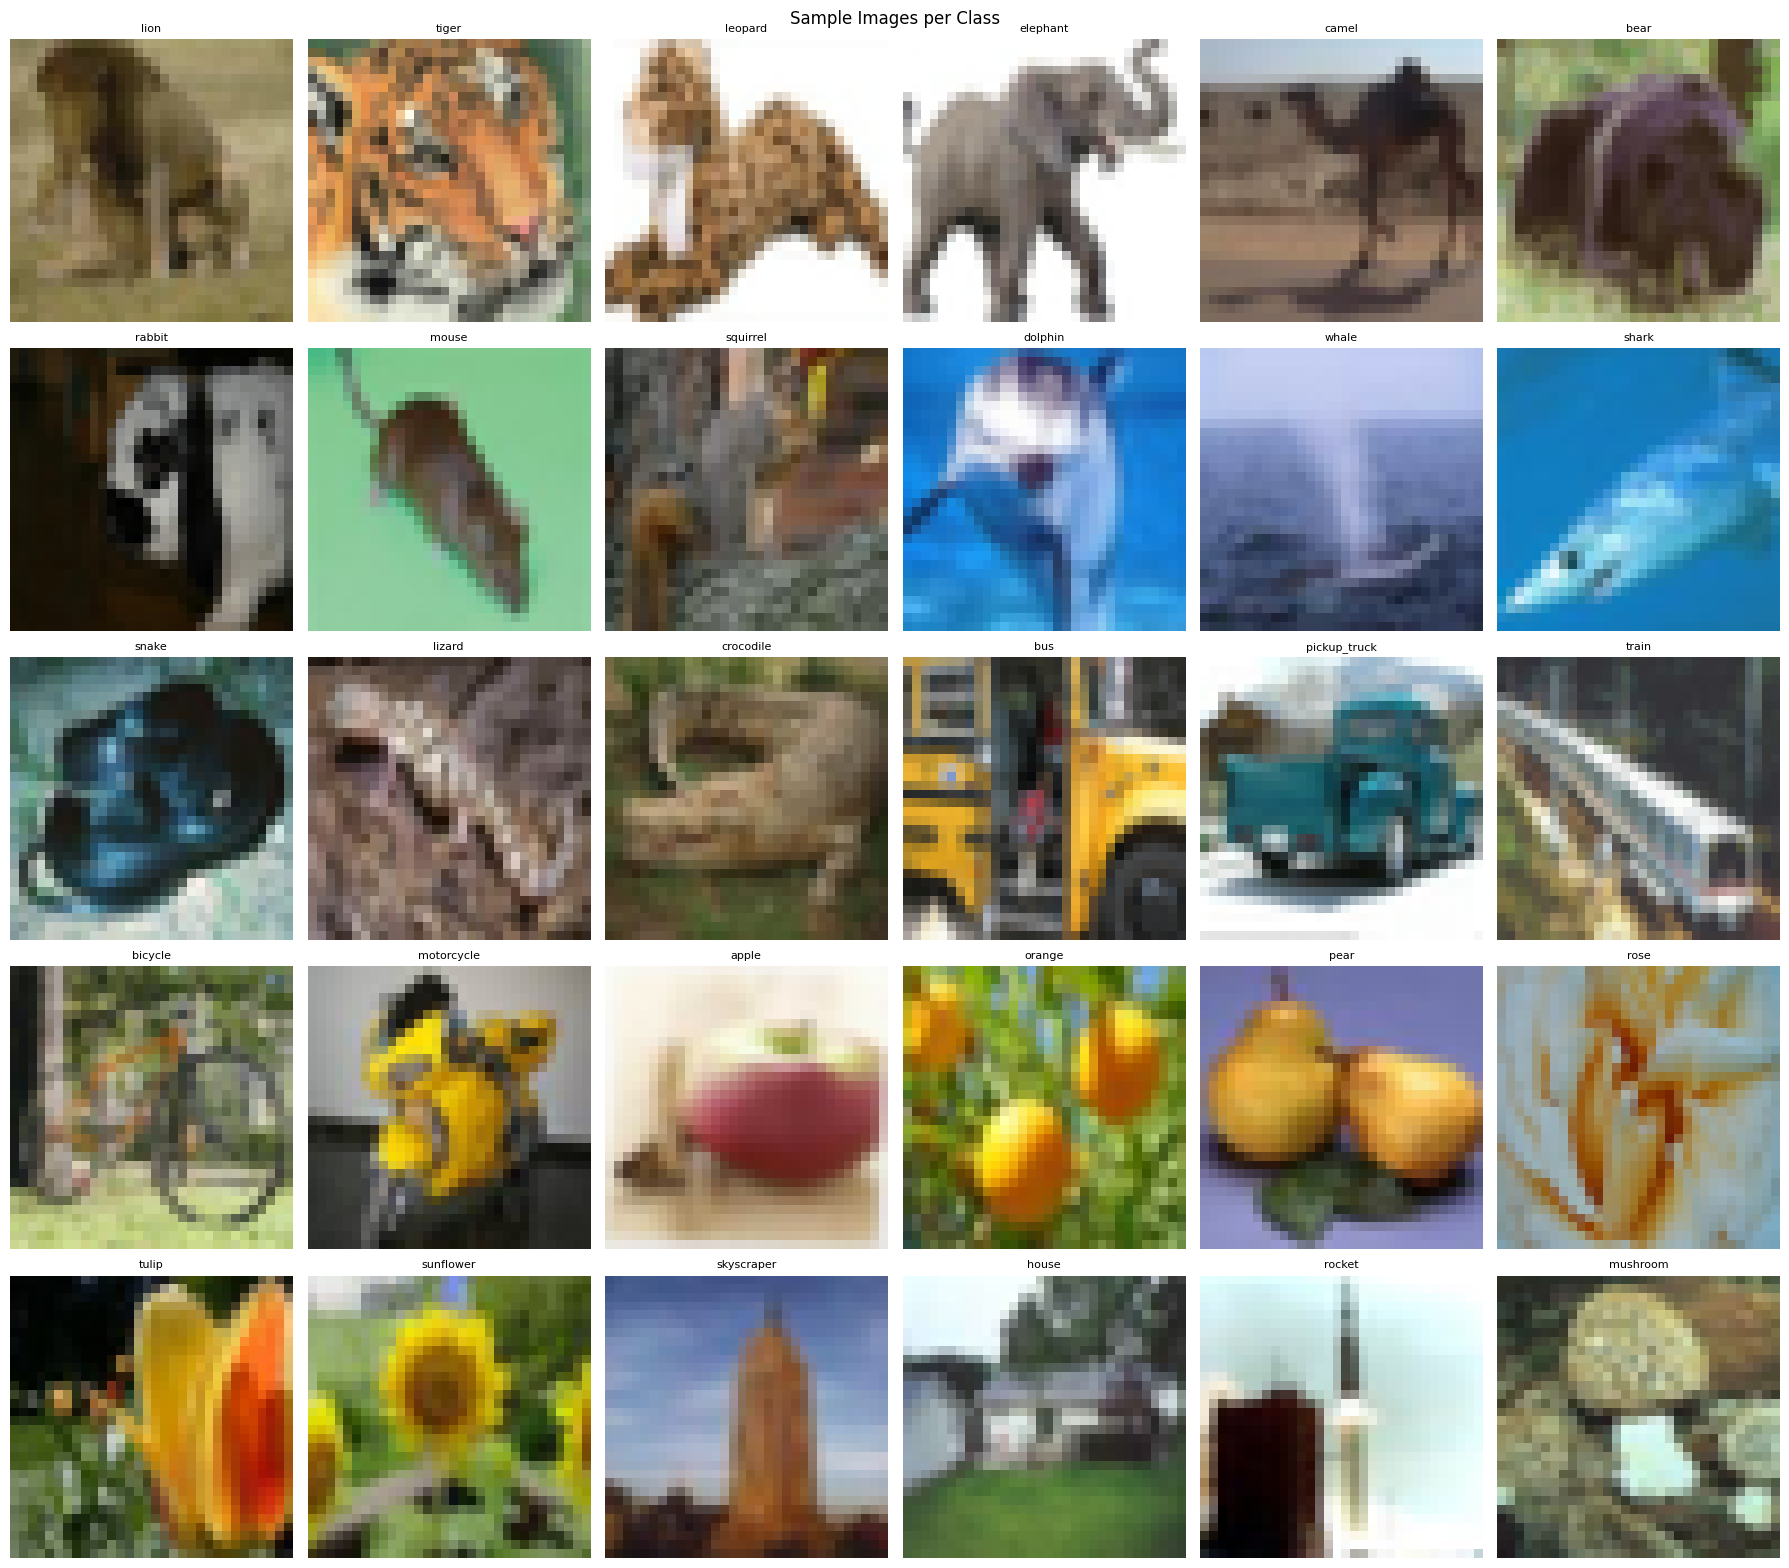

In [6]:
unique, counts = np.unique(y_train, return_counts=True)
df_dist = pd.DataFrame({'class':[SELECTED_CLASSES[i] for i in unique],'count':counts})

plt.figure(figsize=(18,4))
sns.barplot(data=df_dist, x='class', y='count', color='#7c83fd')
plt.xticks(rotation=75, fontsize=8)
plt.title('VisioLearn-30 — Training Samples per Class')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(5,6,figsize=(18,16))
axes = axes.flatten()
for i in range(NUM_CLASSES):
    idx = np.where(y_train==i)[0][0]
    axes[i].imshow(x_train_raw[idx])
    axes[i].set_title(SELECTED_CLASSES[i], fontsize=8)
    axes[i].axis('off')
for j in range(NUM_CLASSES,len(axes)): axes[j].axis('off')
plt.suptitle('Sample Images per Class', fontsize=12)
plt.tight_layout(); plt.show()

## Step 4 — Preprocessing: Resize, Split, One-Hot Encode

In [7]:
def resize_batch(images, size):
    return tf.image.resize(images,[size,size]).numpy().astype('uint8')

print("Resizing training images (32x32 -> 128x128)...")
x_train_rs = resize_batch(x_train_raw, IMG_SIZE)
print("Resizing test images...")
x_test_rs  = resize_batch(x_test_raw,  IMG_SIZE)

x_train, x_val, y_tr_s, y_val = train_test_split(
    x_train_rs, y_train, test_size=0.15,
    random_state=SEED, stratify=y_train
)
y_train_oh = keras.utils.to_categorical(y_tr_s, NUM_CLASSES)
y_val_oh   = keras.utils.to_categorical(y_val,  NUM_CLASSES)
y_test_oh  = keras.utils.to_categorical(y_test, NUM_CLASSES)
print(f"Train:{x_train.shape[0]}  Val:{x_val.shape[0]}  Test:{x_test_rs.shape[0]}")

Resizing training images (32x32 -> 128x128)...


I0000 00:00:1781956690.025914      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781956690.031975      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Resizing test images...
Train:12750  Val:2250  Test:3000


## Step 5 — Data Augmentation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.063245e-05..1.0088245].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00103136..1.0010195].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00026484072..1.0037581].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00013930477..1.0042259].


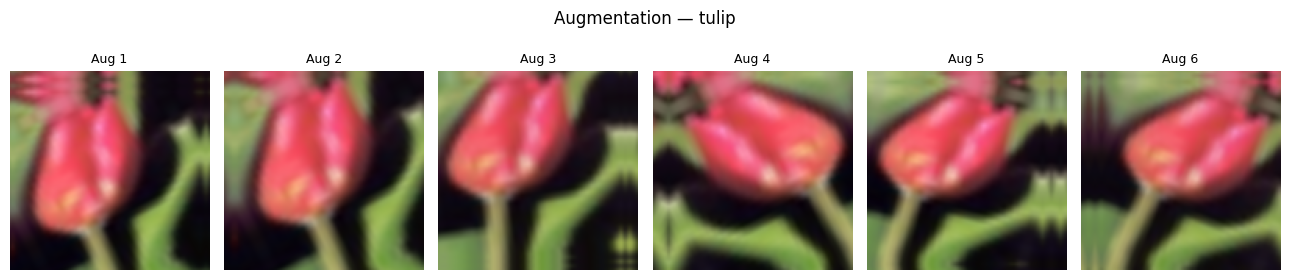

In [8]:
data_aug = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
    layers.RandomTranslation(0.08,0.08),
], name='augmentation')

sample = x_train[0:1]/255.0
plt.figure(figsize=(13,3))
for i in range(6):
    aug = data_aug(sample, training=True)
    plt.subplot(1,6,i+1); plt.imshow(aug[0])
    plt.title(f'Aug {i+1}',fontsize=9); plt.axis('off')
plt.suptitle(f"Augmentation — {SELECTED_CLASSES[y_tr_s[0]]}")
plt.tight_layout(); plt.show()

## Step 5b — tf.data Pipelines

In [9]:
def make_ds(images, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle: ds = ds.shuffle(3000, seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        ds = ds.map(
            lambda x,y: (data_aug(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(x_train,   y_train_oh, augment=True,  shuffle=True)
val_ds   = make_ds(x_val,     y_val_oh,   augment=False, shuffle=False)
test_ds  = make_ds(x_test_rs, y_test_oh,  augment=False, shuffle=False)
print("Pipelines ready: train_ds, val_ds, test_ds")

Pipelines ready: train_ds, val_ds, test_ds


## Step 6 — Transfer Learning Model Builder

In [10]:
# ============================================================
# Uniquely registered preprocessing wrappers per architecture.
# This fixes the Lambda layer deserialization bug when the
# saved model is loaded in VS Code / another session.
# ============================================================

@keras_saving.register_keras_serializable(package='preprocessing')
def preprocess_efficientnetv2b3(x):
    return tf.keras.applications.efficientnet_v2.preprocess_input(x)

@keras_saving.register_keras_serializable(package='preprocessing')
def preprocess_resnet50v2(x):
    return tf.keras.applications.resnet_v2.preprocess_input(x)

@keras_saving.register_keras_serializable(package='preprocessing')
def preprocess_mobilenetv3large(x):
    return tf.keras.applications.mobilenet_v3.preprocess_input(x)

@keras_saving.register_keras_serializable(package='preprocessing')
def preprocess_convnexttiny(x):
    return tf.keras.applications.convnext.preprocess_input(x)

PREPROCESSORS = {
    'EfficientNetV2B3': preprocess_efficientnetv2b3,
    'ResNet50V2':       preprocess_resnet50v2,
    'MobileNetV3Large': preprocess_mobilenetv3large,
    'ConvNeXtTiny':     preprocess_convnexttiny,
}
BASE_CLASSES = {
    'EfficientNetV2B3': EfficientNetV2B3,
    'ResNet50V2':       ResNet50V2,
    'MobileNetV3Large': MobileNetV3Large,
    'ConvNeXtTiny':     ConvNeXtTiny,
}

def build_model(name):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Lambda(PREPROCESSORS[name], name='arch_preprocess')(inputs)
    base = BASE_CLASSES[name](include_top=False, weights='imagenet',
                              input_shape=(IMG_SIZE,IMG_SIZE,3))
    base.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.35)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)
    model = keras.Model(inputs, out, name=f'{name}_transfer')
    model.compile(optimizer=keras.optimizers.Adam(LR),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def get_callbacks(name):
    return [
        keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,
                                       restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,
                                           patience=3,min_lr=1e-6),
        keras.callbacks.ModelCheckpoint(f'/content/{name}_ckpt.keras',
                                         monitor='val_accuracy',save_best_only=True),
    ]

print("build_model() ready for all 4 architectures.")

build_model() ready for all 4 architectures.


## Step 7a — Train EfficientNetV2B3

In [ ]:
mlflow.set_experiment(EXPERIMENT_NAME)
with mlflow.start_run(run_name='EfficientNetV2B3'):
    mlflow.log_params({'model':'EfficientNetV2B3','img_size':IMG_SIZE,
                        'batch_size':BATCH_SIZE,'epochs':EPOCHS,'lr':LR,
                        'num_classes':NUM_CLASSES,'project':'VisioLearn-30'})
    model_effnet = build_model('EfficientNetV2B3')
    t0 = time.time()
    history_effnet = model_effnet.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS, callbacks=get_callbacks('EfficientNetV2B3'), verbose=1
    )
    elapsed = time.time()-t0
    bv = max(history_effnet.history['val_accuracy'])
    bl = min(history_effnet.history['val_loss'])
    # Log per-epoch metrics for interactive charts in MLflow UI
    for ep,(acc,val_acc,loss,val_loss) in enumerate(zip(
        history_effnet.history['accuracy'],
        history_effnet.history['val_accuracy'],
        history_effnet.history['loss'],
        history_effnet.history['val_loss']
    )):
        mlflow.log_metrics({
            'train_accuracy':acc,'val_accuracy':val_acc,
            'train_loss':loss,'val_loss':val_loss
        }, step=ep+1)
    mlflow.log_metrics({'best_val_accuracy':round(bv,4),
                         'best_val_loss':round(bl,4),
                         'train_time_s':round(elapsed,1)})
    print(f"EfficientNetV2B3: {elapsed:.0f}s | best_val_acc={bv:.4f}")

2026/06/20 11:58:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/20 11:58:25 INFO mlflow.store.db.utils: Updating database tables
2026/06/20 11:58:27 INFO mlflow.tracking.fluent: Experiment with name 'VisioLearn-30' does not exist. Creating a new experiment.


52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


I0000 00:00:1781956726.538014     178 service.cc:152] XLA service 0x299b2430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781956726.538061     178 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781956726.538066     178 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781956730.027674     178 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-20 11:58:57.637781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:58:57.770848: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:58:58.563974: E external/local_xla/xl

  3/399 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.0191 - loss: 3.5708   

I0000 00:00:1781956751.944766     178 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4766 - loss: 1.8278

2026-06-20 11:59:44.072188: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:59:44.205880: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:59:45.029084: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:59:45.164312: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:59:46.571039: E external/local_xla/xla/stream_

399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.4769 - loss: 1.8268

2026-06-20 12:00:11.616504: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:00:11.747759: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:00:12.538133: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:00:12.672516: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:00:14.059322: E external/local_xla/xla/stream_

399/399 ━━━━━━━━━━━━━━━━━━━━ 108s 167ms/step - accuracy: 0.5821 - loss: 1.4045 - val_accuracy: 0.7880 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.6783 - loss: 1.0374 - val_accuracy: 0.8036 - val_loss: 0.6390 - learning_rate: 0.0010
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.6975 - loss: 0.9588 - val_accuracy: 0.8147 - val_loss: 0.6210 - learning_rate: 0.0010
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - accuracy: 0.7056 - loss: 0.9204 - val_accuracy: 0.8036 - val_loss: 0.6333 - learning_rate: 0.0010
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - accuracy: 0.7165 - loss: 0.8835 - val_accuracy: 0.8111 - val_loss: 0.6168 - learning_rate: 0.0010
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.7126 - loss: 0.8900 - val_accuracy: 0.8160 - val_loss: 0.6102 - learning_rate: 0.0010
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.7260 - loss: 0.85

## Step 7b — Train ResNet50V2

In [12]:
mlflow.set_experiment(EXPERIMENT_NAME)
with mlflow.start_run(run_name='ResNet50V2'):
    mlflow.log_params({'model':'ResNet50V2','img_size':IMG_SIZE,
                        'batch_size':BATCH_SIZE,'epochs':EPOCHS,'lr':LR,
                        'num_classes':NUM_CLASSES,'project':'VisioLearn-30'})
    model_resnet = build_model('ResNet50V2')
    t0 = time.time()
    history_resnet = model_resnet.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS, callbacks=get_callbacks('ResNet50V2'), verbose=1
    )
    elapsed = time.time()-t0
    bv = max(history_resnet.history['val_accuracy'])
    bl = min(history_resnet.history['val_loss'])
    # Log per-epoch metrics for interactive charts in MLflow UI
    for ep,(acc,val_acc,loss,val_loss) in enumerate(zip(
        history_resnet.history['accuracy'],
        history_resnet.history['val_accuracy'],
        history_resnet.history['loss'],
        history_resnet.history['val_loss']
    )):
        mlflow.log_metrics({
            'train_accuracy':acc,'val_accuracy':val_acc,
            'train_loss':loss,'val_loss':val_loss
        }, step=ep+1)
    mlflow.log_metrics({'best_val_accuracy':round(bv,4),
                         'best_val_loss':round(bl,4),
                         'train_time_s':round(elapsed,1)})
    print(f"ResNet50V2: {elapsed:.0f}s | best_val_acc={bv:.4f}")

399/399 ━━━━━━━━━━━━━━━━━━━━ 51s 98ms/step - accuracy: 0.5031 - loss: 1.7950 - val_accuracy: 0.6622 - val_loss: 1.0469 - learning_rate: 0.0010
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 27s 66ms/step - accuracy: 0.5962 - loss: 1.3258 - val_accuracy: 0.6951 - val_loss: 0.9734 - learning_rate: 0.0010
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 27s 66ms/step - accuracy: 0.6245 - loss: 1.2176 - val_accuracy: 0.7080 - val_loss: 0.9069 - learning_rate: 0.0010
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 27s 66ms/step - accuracy: 0.6350 - loss: 1.1640 - val_accuracy: 0.7249 - val_loss: 0.8839 - learning_rate: 0.0010
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - accuracy: 0.6463 - loss: 1.1352 - val_accuracy: 0.7196 - val_loss: 0.9093 - learning_rate: 0.0010
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - accuracy: 0.6650 - loss: 1.0744 - val_accuracy: 0.7187 - val_loss: 0.8980 - learning_rate: 0.0010
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - accuracy: 0.6565 - loss: 1.0816

## Step 7c — Train MobileNetV3Large

In [13]:
mlflow.set_experiment(EXPERIMENT_NAME)
with mlflow.start_run(run_name='MobileNetV3Large'):
    mlflow.log_params({'model':'MobileNetV3Large','img_size':IMG_SIZE,
                        'batch_size':BATCH_SIZE,'epochs':EPOCHS,'lr':LR,
                        'num_classes':NUM_CLASSES,'project':'VisioLearn-30'})
    model_mobilenet = build_model('MobileNetV3Large')
    t0 = time.time()
    history_mobilenet = model_mobilenet.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS, callbacks=get_callbacks('MobileNetV3Large'), verbose=1
    )
    elapsed = time.time()-t0
    bv = max(history_mobilenet.history['val_accuracy'])
    bl = min(history_mobilenet.history['val_loss'])
    # Log per-epoch metrics for interactive charts in MLflow UI
    for ep,(acc,val_acc,loss,val_loss) in enumerate(zip(
        history_mobilenet.history['accuracy'],
        history_mobilenet.history['val_accuracy'],
        history_mobilenet.history['loss'],
        history_mobilenet.history['val_loss']
    )):
        mlflow.log_metrics({
            'train_accuracy':acc,'val_accuracy':val_acc,
            'train_loss':loss,'val_loss':val_loss
        }, step=ep+1)
    mlflow.log_metrics({'best_val_accuracy':round(bv,4),
                         'best_val_loss':round(bl,4),
                         'train_time_s':round(elapsed,1)})
    print(f"MobileNetV3Large: {elapsed:.0f}s | best_val_acc={bv:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


2026-06-20 12:18:05.909273: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:18:06.046425: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


397/399 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4277 - loss: 2.0479

2026-06-20 12:18:39.390507: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:18:39.525802: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4282 - loss: 2.0455

2026-06-20 12:18:54.303486: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:18:54.440356: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


399/399 ━━━━━━━━━━━━━━━━━━━━ 65s 121ms/step - accuracy: 0.5365 - loss: 1.5690 - val_accuracy: 0.7622 - val_loss: 0.7483 - learning_rate: 0.0010
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.6379 - loss: 1.1530 - val_accuracy: 0.7600 - val_loss: 0.7149 - learning_rate: 0.0010
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.6697 - loss: 1.0425 - val_accuracy: 0.7764 - val_loss: 0.6740 - learning_rate: 0.0010
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.6885 - loss: 0.9853 - val_accuracy: 0.7916 - val_loss: 0.6427 - learning_rate: 0.0010
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.7005 - loss: 0.9442 - val_accuracy: 0.7938 - val_loss: 0.6425 - learning_rate: 0.0010
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.7056 - loss: 0.9074 - val_accuracy: 0.7898 - val_loss: 0.6335 - learning_rate: 0.0010
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.7173 - loss: 0.889

## Step 7d — Train ConvNeXtTiny

In [14]:
mlflow.set_experiment(EXPERIMENT_NAME)
with mlflow.start_run(run_name='ConvNeXtTiny'):
    mlflow.log_params({'model':'ConvNeXtTiny','img_size':IMG_SIZE,
                        'batch_size':BATCH_SIZE,'epochs':EPOCHS,'lr':LR,
                        'num_classes':NUM_CLASSES,'project':'VisioLearn-30'})
    model_convnext = build_model('ConvNeXtTiny')
    t0 = time.time()
    history_convnext = model_convnext.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS, callbacks=get_callbacks('ConvNeXtTiny'), verbose=1
    )
    elapsed = time.time()-t0
    bv = max(history_convnext.history['val_accuracy'])
    bl = min(history_convnext.history['val_loss'])
    # Log per-epoch metrics for interactive charts in MLflow UI
    for ep,(acc,val_acc,loss,val_loss) in enumerate(zip(
        history_convnext.history['accuracy'],
        history_convnext.history['val_accuracy'],
        history_convnext.history['loss'],
        history_convnext.history['val_loss']
    )):
        mlflow.log_metrics({
            'train_accuracy':acc,'val_accuracy':val_acc,
            'train_loss':loss,'val_loss':val_loss
        }, step=ep+1)
    mlflow.log_metrics({'best_val_accuracy':round(bv,4),
                         'best_val_loss':round(bl,4),
                         'train_time_s':round(elapsed,1)})
    print(f"ConvNeXtTiny: {elapsed:.0f}s | best_val_acc={bv:.4f}")

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


2026-06-20 12:26:49.789601: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:26:49.924883: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


397/399 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4906 - loss: 1.8286

2026-06-20 12:27:20.489128: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:27:20.624069: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4911 - loss: 1.8263

2026-06-20 12:27:32.706478: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:27:32.841510: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


399/399 ━━━━━━━━━━━━━━━━━━━━ 57s 108ms/step - accuracy: 0.5980 - loss: 1.3685 - val_accuracy: 0.7987 - val_loss: 0.6564 - learning_rate: 0.0010
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.7110 - loss: 0.9394 - val_accuracy: 0.8182 - val_loss: 0.6012 - learning_rate: 0.0010
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.7268 - loss: 0.8621 - val_accuracy: 0.8302 - val_loss: 0.5647 - learning_rate: 0.0010
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.7384 - loss: 0.8018 - val_accuracy: 0.8298 - val_loss: 0.5485 - learning_rate: 0.0010
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.7508 - loss: 0.7686 - val_accuracy: 0.8320 - val_loss: 0.5494 - learning_rate: 0.0010
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 28s 68ms/step - accuracy: 0.7565 - loss: 0.7608 - val_accuracy: 0.8284 - val_loss: 0.5428 - learning_rate: 0.0010
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 28s 68ms/step - accuracy: 0.7592 - loss: 0.732

## Step 8a — Training Accuracy & Loss Curves

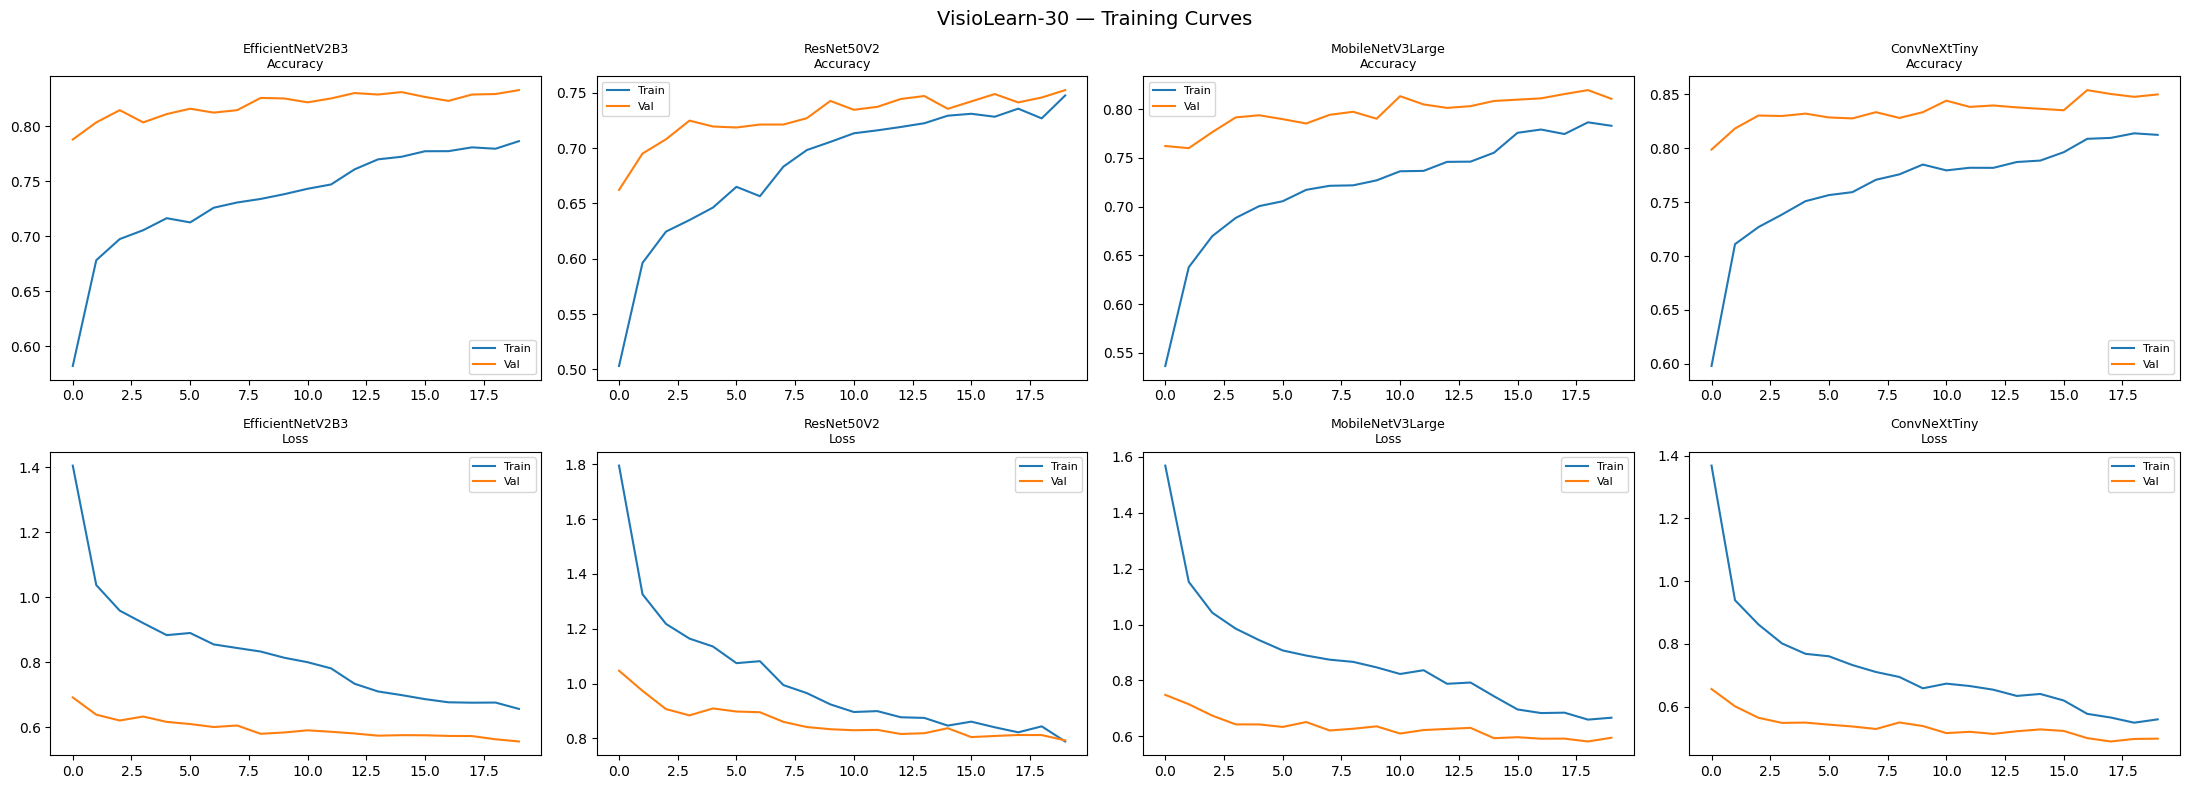

Saved: training_curves.png


In [15]:
all_histories = {
    'EfficientNetV2B3': history_effnet,
    'ResNet50V2':       history_resnet,
    'MobileNetV3Large': history_mobilenet,
    'ConvNeXtTiny':     history_convnext,
}
fig, axes = plt.subplots(2,4,figsize=(22,8))
for col,(name,h) in enumerate(all_histories.items()):
    axes[0,col].plot(h.history['accuracy'],label='Train')
    axes[0,col].plot(h.history['val_accuracy'],label='Val')
    axes[0,col].set_title(f'{name}\nAccuracy',fontsize=9)
    axes[0,col].legend(fontsize=8)
    axes[1,col].plot(h.history['loss'],label='Train')
    axes[1,col].plot(h.history['val_loss'],label='Val')
    axes[1,col].set_title(f'{name}\nLoss',fontsize=9)
    axes[1,col].legend(fontsize=8)
plt.suptitle('VisioLearn-30 — Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('/content/training_curves.png',dpi=130,bbox_inches='tight')
plt.show(); print('Saved: training_curves.png')

## Step 8b — Model Comparison Table

In [16]:
all_models = {
    'EfficientNetV2B3': model_effnet,
    'ResNet50V2':       model_resnet,
    'MobileNetV3Large': model_mobilenet,
    'ConvNeXtTiny':     model_convnext,
}
all_preds = {}; results = []
for name, model in all_models.items():
    probs = model.predict(test_ds, verbose=0)
    preds = np.argmax(probs, axis=1)
    all_preds[name] = {'probs':probs,'classes':preds}
    _,acc = model.evaluate(test_ds, verbose=0)
    p = precision_score(y_test,preds,average='weighted',zero_division=0)
    r = recall_score(y_test,preds,average='weighted',zero_division=0)
    f = f1_score(y_test,preds,average='weighted',zero_division=0)
    results.append({'Model':name,'Accuracy':round(acc,4),
                    'Precision':round(p,4),'Recall':round(r,4),'F1':round(f,4)})
df_results = pd.DataFrame(results).sort_values('Accuracy',ascending=False)
print("\n===== VisioLearn-30 MODEL COMPARISON =====")
print(df_results.to_string(index=False))
best_model_name = df_results.iloc[0]['Model']
best_model  = all_models[best_model_name]
best_preds  = all_preds[best_model_name]['classes']
best_probs  = all_preds[best_model_name]['probs']
print(f"\nBest: {best_model_name} ({df_results.iloc[0]['Accuracy']*100:.2f}%)")

2026-06-20 12:36:42.324360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:36:42.458560: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:36:43.243621: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:36:43.379117: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:36:44.738329: E external/local_xla/xla/stream_


===== VisioLearn-30 MODEL COMPARISON =====
           Model  Accuracy  Precision  Recall     F1
    ConvNeXtTiny    0.8477     0.8489  0.8477 0.8474
EfficientNetV2B3    0.8397     0.8435  0.8397 0.8396
MobileNetV3Large    0.8053     0.8067  0.8053 0.8035
      ResNet50V2    0.7520     0.7543  0.7520 0.7513

Best: ConvNeXtTiny (84.77%)


## Step 8c — Confusion Matrix

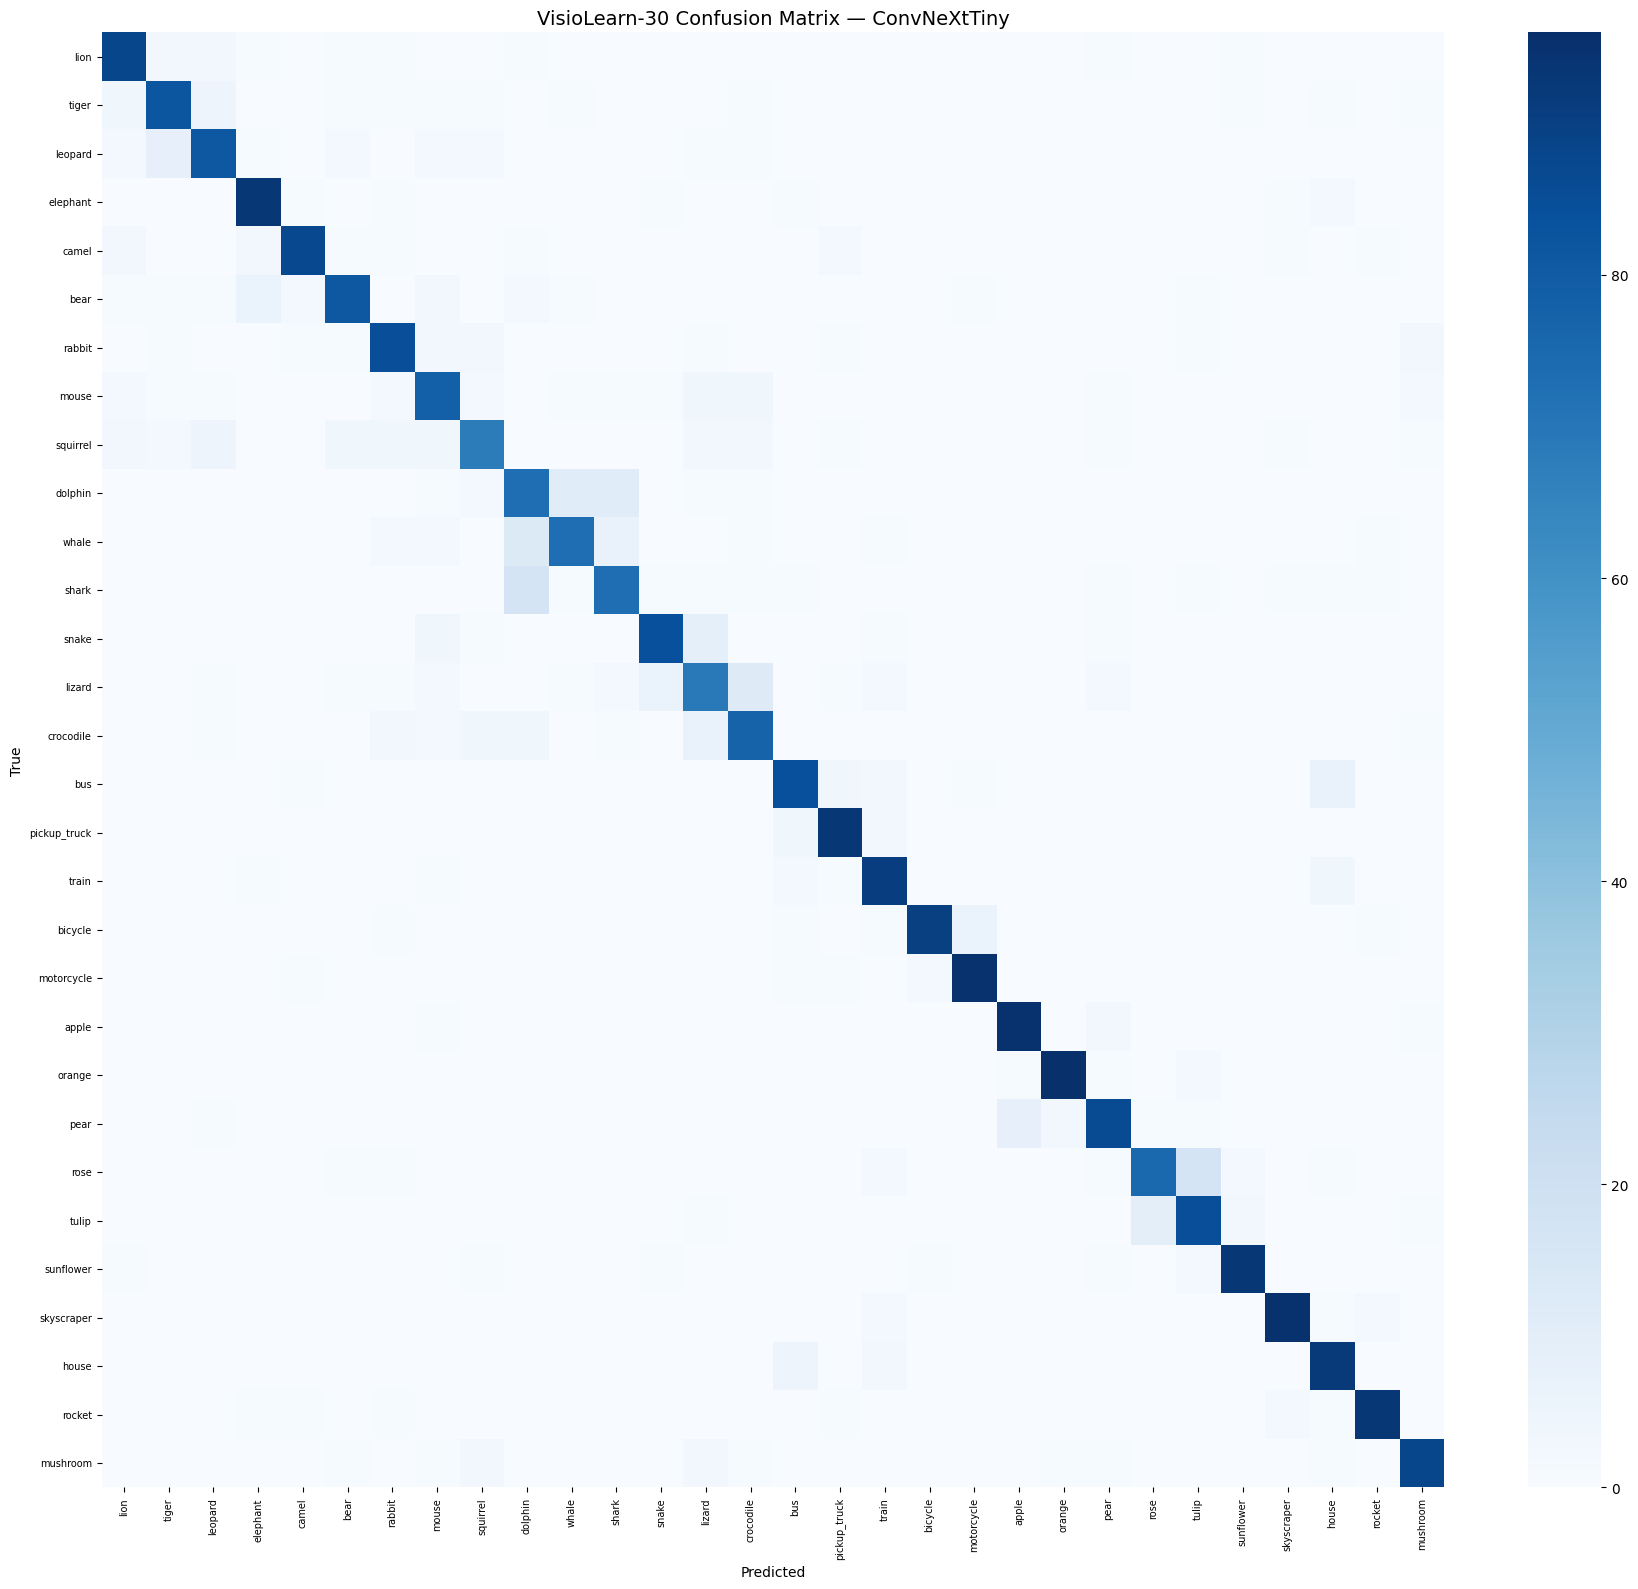

Saved: confusion_matrix.png
              precision    recall  f1-score   support

        lion       0.85      0.88      0.86       100
       tiger       0.84      0.82      0.83       100
     leopard       0.82      0.81      0.81       100
    elephant       0.88      0.93      0.90       100
       camel       0.93      0.87      0.90       100
        bear       0.86      0.81      0.84       100
      rabbit       0.82      0.85      0.83       100
       mouse       0.74      0.78      0.76       100
    squirrel       0.78      0.68      0.73       100
     dolphin       0.66      0.73      0.69       100
       whale       0.82      0.73      0.77       100
       shark       0.77      0.73      0.75       100
       snake       0.89      0.84      0.87       100
      lizard       0.69      0.69      0.69       100
   crocodile       0.75      0.77      0.76       100
         bus       0.85      0.84      0.84       100
pickup_truck       0.89      0.93      0.91       100

In [17]:
cm = confusion_matrix(y_test, best_preds)
fig,ax = plt.subplots(figsize=(18,16))
sns.heatmap(cm,annot=False,fmt='d',cmap='Blues',
            xticklabels=SELECTED_CLASSES,yticklabels=SELECTED_CLASSES,ax=ax)
ax.set_title(f'VisioLearn-30 Confusion Matrix — {best_model_name}',fontsize=14)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=90,fontsize=7); plt.yticks(rotation=0,fontsize=7)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png',dpi=130,bbox_inches='tight')
plt.show(); print('Saved: confusion_matrix.png')
print(classification_report(y_test,best_preds,target_names=SELECTED_CLASSES,zero_division=0))

## Step 8d — ROC Curves

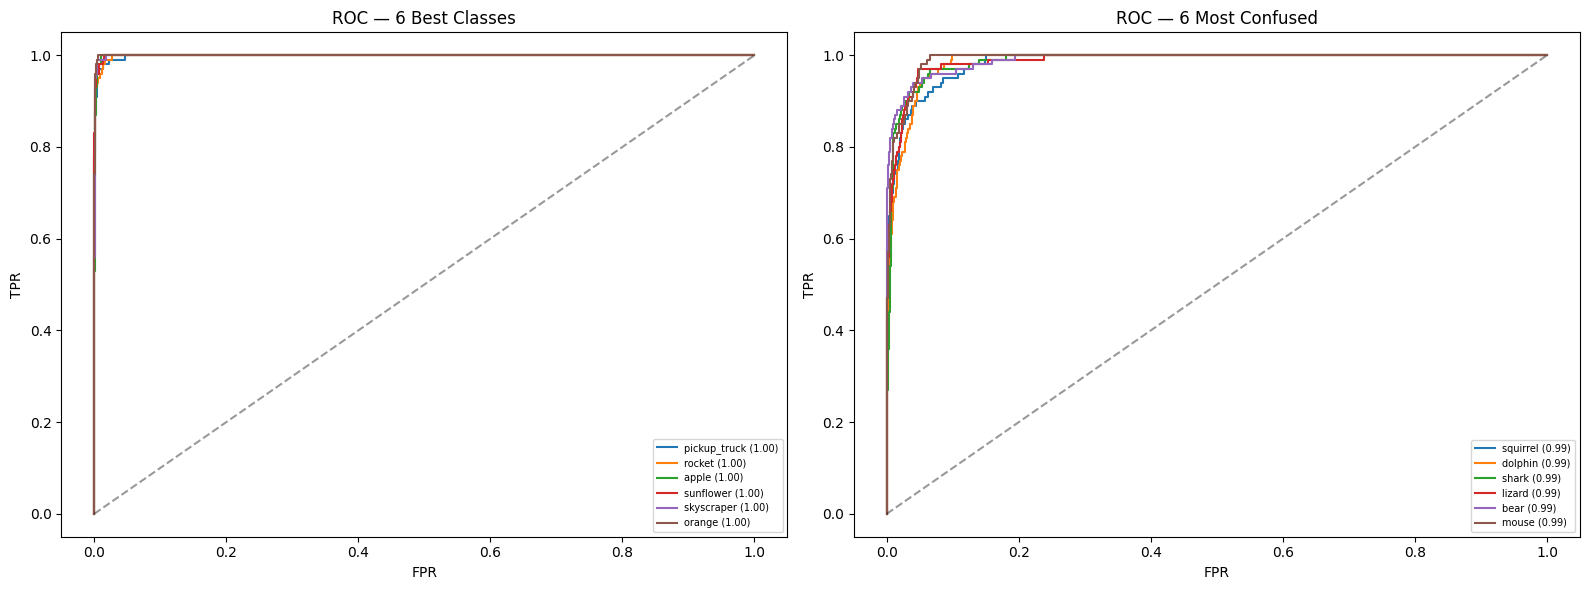

Mean AUC: 0.9945


In [18]:
y_bin = label_binarize(y_test, classes=range(NUM_CLASSES))
fpr_d,tpr_d,auc_d = {},{},{}
for i in range(NUM_CLASSES):
    fpr_d[i],tpr_d[i],_ = roc_curve(y_bin[:,i],best_probs[:,i])
    auc_d[i] = auc(fpr_d[i],tpr_d[i])
sorted_auc = sorted(auc_d.items(),key=lambda x:x[1])
worst6=sorted_auc[:6]; best6=sorted_auc[-6:]
fig,axes = plt.subplots(1,2,figsize=(16,6))
for idx,v in best6:
    axes[0].plot(fpr_d[idx],tpr_d[idx],label=f'{SELECTED_CLASSES[idx]} ({v:.2f})')
axes[0].plot([0,1],[0,1],'k--',alpha=.4)
axes[0].set_title('ROC — 6 Best Classes'); axes[0].legend(fontsize=7)
for idx,v in worst6:
    axes[1].plot(fpr_d[idx],tpr_d[idx],label=f'{SELECTED_CLASSES[idx]} ({v:.2f})')
axes[1].plot([0,1],[0,1],'k--',alpha=.4)
axes[1].set_title('ROC — 6 Most Confused'); axes[1].legend(fontsize=7)
for ax in axes: ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
plt.tight_layout()
plt.savefig('/content/roc_curves.png',dpi=130,bbox_inches='tight')
plt.show()
print(f"Mean AUC: {np.mean(list(auc_d.values())):.4f}")

## Step 8e — Sample Predictions

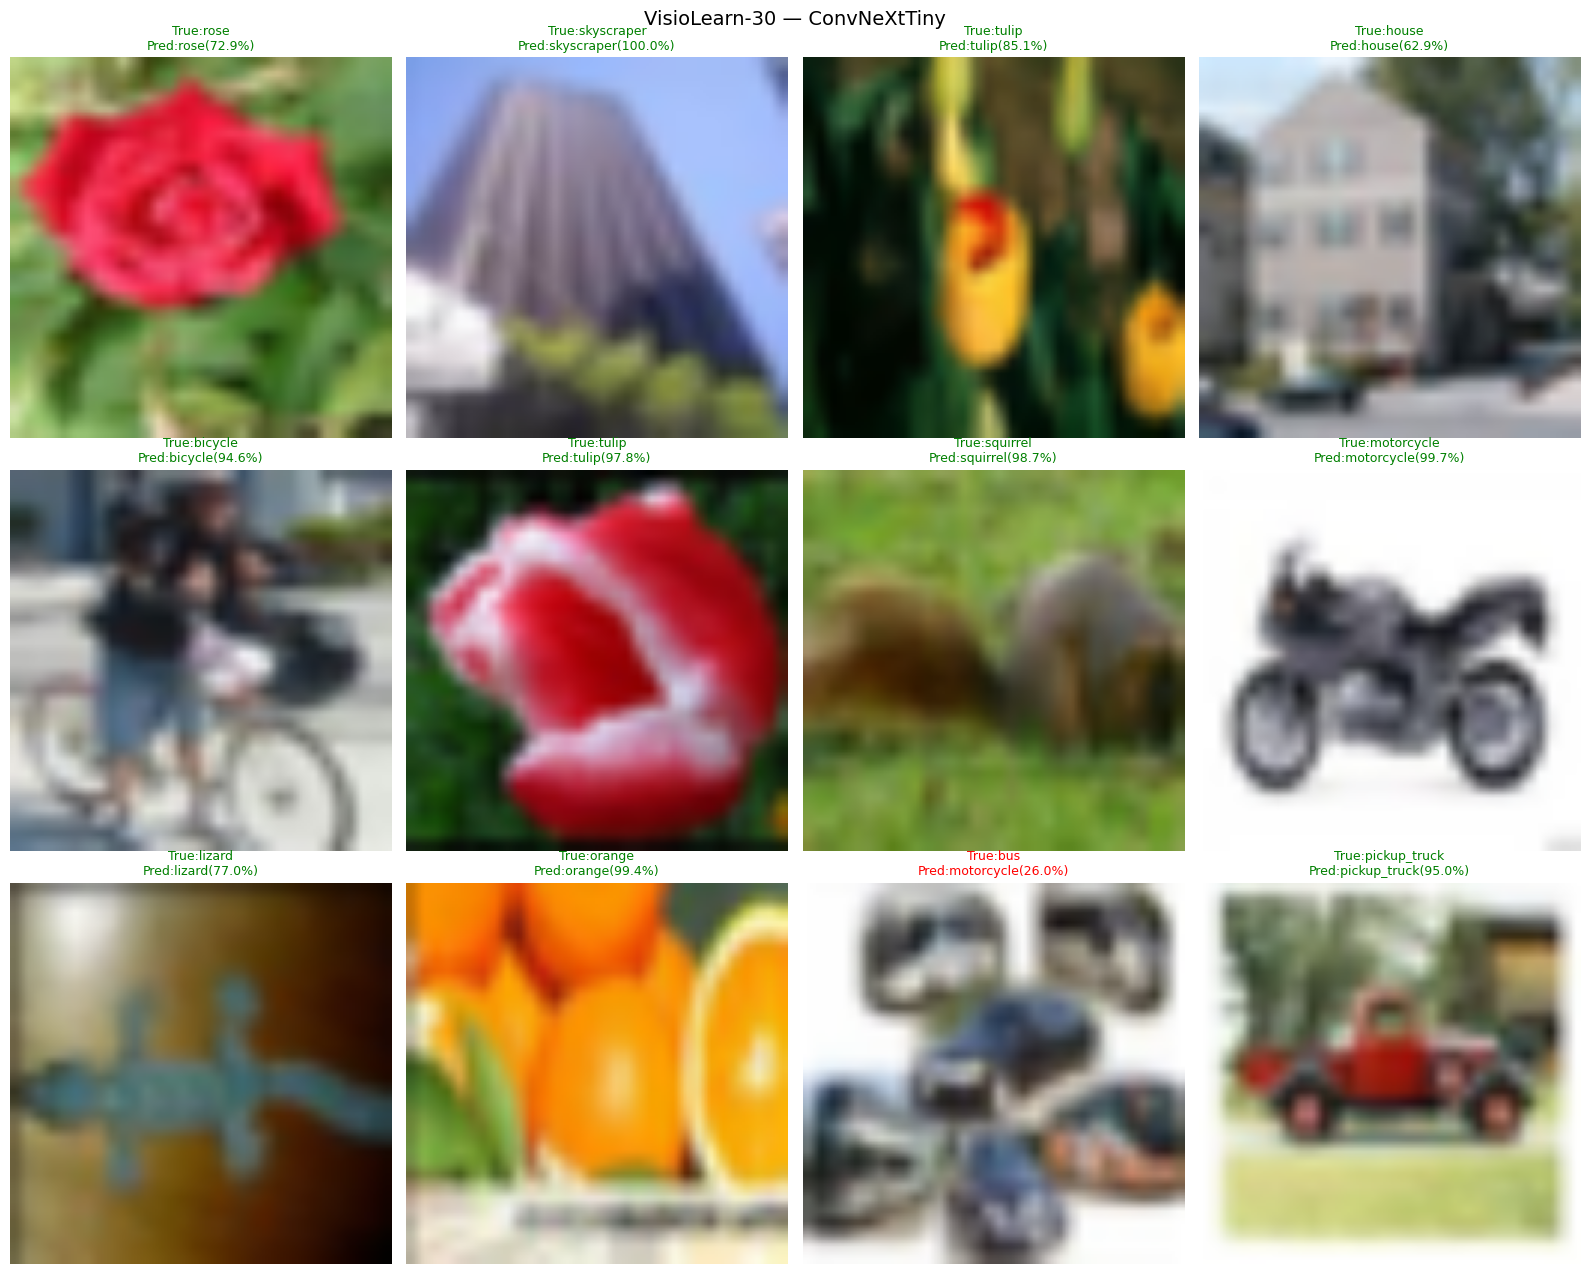

In [19]:
np.random.seed(SEED)
idxs = np.random.choice(len(x_test_rs),12,replace=False)
fig,axes = plt.subplots(3,4,figsize=(16,13))
axes = axes.flatten()
for pi,ti in enumerate(idxs):
    true_l = SELECTED_CLASSES[y_test[ti]]
    pi2    = best_preds[ti]
    pred_l = SELECTED_CLASSES[pi2]
    conf   = best_probs[ti][pi2]
    color  = 'green' if pi2==y_test[ti] else 'red'
    axes[pi].imshow(x_test_rs[ti])
    axes[pi].set_title(f'True:{true_l}\nPred:{pred_l}({conf:.1%})',
                       color=color,fontsize=9)
    axes[pi].axis('off')
plt.suptitle(f'VisioLearn-30 — {best_model_name}',fontsize=14)
plt.tight_layout()
plt.savefig('/content/sample_predictions.png',dpi=130,bbox_inches='tight')
plt.show()

## Step 9 — Log All Artifacts to MLflow

In [20]:
# ============================================================
# Log all PNG charts + comparison CSV to MLflow.
# These will appear in MLflow UI as clickable artifact images.
# ============================================================

mlflow.set_experiment(EXPERIMENT_NAME)
with mlflow.start_run(run_name='VisioLearn30_Artifacts'):
    mlflow.set_tag('project', 'VisioLearn-30')
    mlflow.set_tag('best_model', best_model_name)
    mlflow.set_tag('num_classes', str(NUM_CLASSES))
    for row in results:
        mlflow.log_metrics({
            f"{row['Model']}_test_acc": row['Accuracy'],
            f"{row['Model']}_f1":       row['F1'],
        })
    for png in ['/content/training_curves.png','/content/confusion_matrix.png',
                '/content/roc_curves.png','/content/sample_predictions.png']:
        import os
        if os.path.exists(png):
            mlflow.log_artifact(png)
            print(f"Logged: {png}")
print("MLflow artifacts logged.")

Logged: /content/training_curves.png
Logged: /content/confusion_matrix.png
Logged: /content/roc_curves.png
Logged: /content/sample_predictions.png
MLflow artifacts logged.


## Step 10 — Save Model & Copy to Google Drive

In [21]:
# ============================================================
# SAVE FILES EXACTLY IN THE HIGHLIGHTED FOLDER
# ============================================================
import os
import json

# Aapka wo folder jo aapne highlight kiya hai
save_dir = '/kaggle/working/VisioLearn-30/models'

# Folder ensure karna (agar hai toh koi farq nahi parta)
os.makedirs(save_dir, exist_ok=True)

# 1. Model save karo
best_model.save(f'{save_dir}/best_model.keras')

# 2. Class names save karo (Agar aapke code mein variable ka naam alag hai toh change karo)
with open(f'{save_dir}/class_names.json', 'w') as f:
    json.dump(SELECTED_CLASSES, f) # <-- Check if variable name is correct

# 3. CSV save karo
df_results.to_csv(f'{save_dir}/model_comparison.csv', index=False)

print(f"✅ Saari files successfully yahan save ho gayi: {save_dir}")

✅ Saari files successfully yahan save ho gayi: /kaggle/working/VisioLearn-30/models


## Step 11 — Export MLflow Runs for VS Code Dashboard

In [24]:
# ============================================================
# Zip the mlruns/ folder so you can download it from Kaggle's
# Output panel and use it in VS Code MLflow UI.
# Run: python scripts/run_mlflow.py  (in VS Code)
# ============================================================

import shutil, os

# In Kaggle, MLflow saves runs in the working directory
mlruns_dir = '/kaggle/working/mlruns'
zip_path = '/kaggle/working/mlruns_export.zip'

# Check if the mlruns folder exists
if os.path.exists(mlruns_dir):
    # Remove old zip file if it already exists to save space
    if os.path.exists(zip_path):
        os.remove(zip_path)
        
    # Create a new zip file of the mlruns folder
    shutil.make_archive(zip_path.replace('.zip', ''), 'zip', '/kaggle/working', 'mlruns')
    
    # Calculate and print the zip file size
    size_kb = os.path.getsize(zip_path) / 1024
    if size_kb > 1024:
        print(f"✓ mlruns_export.zip created ({size_kb/1024:.1f} MB)")
    else:
        print(f"✓ mlruns_export.zip created ({size_kb:.1f} KB)")
        
    print("\n📥 HOW TO DOWNLOAD:")
    print("1. Look at the RIGHT SIDE panel in Kaggle.")
    print("2. Click on the 'Output' tab.")
    print("3. Click the download icon next to 'mlruns_export.zip'.")
    print("\n💻 NEXT STEPS (In VS Code):")
    print("1. Extract the zip file.")
    print("2. Copy 'mlruns/' folder into your 'VisioLearn-30' project folder.")
    print("3. Run: python scripts/run_mlflow.py")
    print("4. MLflow UI opens at: http://localhost:5001")
else:
    print("❌ Error: 'mlruns' folder not found. Did the training run correctly?")

✓ mlruns_export.zip created (745.3 KB)

📥 HOW TO DOWNLOAD:
1. Look at the RIGHT SIDE panel in Kaggle.
2. Click on the 'Output' tab.
3. Click the download icon next to 'mlruns_export.zip'.

💻 NEXT STEPS (In VS Code):
1. Extract the zip file.
2. Copy 'mlruns/' folder into your 'VisioLearn-30' project folder.
3. Run: python scripts/run_mlflow.py
4. MLflow UI opens at: http://localhost:5001


## Step 12 — Quick Gradio Demo (in-notebook test)

In [27]:
loaded_model = keras.models.load_model(
    '/kaggle/working/VisioLearn-30/models/best_model.keras',
    custom_objects={
        'preprocess_efficientnetv2b3': preprocess_efficientnetv2b3,
        'preprocess_resnet50v2':       preprocess_resnet50v2,
        'preprocess_mobilenetv3large': preprocess_mobilenetv3large,
        'preprocess_convnexttiny':     preprocess_convnexttiny,
    }
)
with open('/kaggle/working/VisioLearn-30/models/class_names.json') as f: loaded_cls = json.load(f)

def predict_fn(img):
    if img is None: return None
    arr = np.expand_dims(np.array(img.resize((IMG_SIZE,IMG_SIZE)),dtype='float32'),0)
    p   = loaded_model.predict(arr, verbose=0)[0]
    return {loaded_cls[i]: float(p[i]) for i in range(len(loaded_cls))}

gr.Interface(
    fn=predict_fn,
    inputs=gr.Image(type='pil', label='Upload Image'),
    outputs=gr.Label(num_top_classes=5, label='Top-5 Predictions'),
    title=f'VisioLearn-30 — {best_model_name}',
    description=f'30-class classifier | Test accuracy: {df_results.iloc[0]["Accuracy"]*100:.2f}%',
    allow_flagging='never',
).launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://072dcd2bdf2006eac7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


2026-06-20 12:50:08.917466: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 12:50:09.050338: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


In [ ]:
# ---------------------------------------------------------
# UPLOAD TO HUGGING FACE (FROM EXACT HIGHLIGHTED FOLDER)
# ---------------------------------------------------------
!pip install -q huggingface_hub

from huggingface_hub import HfApi, login

# LOGIN
login(token="YOUR_HF_TOKEN_HERE") # Apna token yahan daalo

# REPO DETAILS
username = "chabdullah0566" 
repo_name = "Omnivision_Classifier"
repo_id = f"{username}/{repo_name}"

api = HfApi()
api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)

# Directly us folder se files uthayenge
base_path = '/kaggle/working/VisioLearn-30/models/'
files_to_upload = [
    "best_model.keras",
    "class_names.json",
    "model_comparison.csv"
]

print("Uploading to Hugging Face...")
for file_name in files_to_upload:
    exact_file_path = base_path + file_name
    
    if os.path.exists(exact_file_path):
        print(f"  ⏳ Uploading {file_name}...")
        api.upload_file(
            path_or_fileobj=exact_file_path,
            path_in_repo=file_name,
            repo_id=repo_id,
            repo_type="model",
            commit_message=f"Upload {file_name}"
        )
        print(f"  ✅ {file_name} done!")
    else:
        print(f"  ❌ {file_name} not found at {exact_file_path}")

print("\n" + "="*50)
print(f"✅ Done! View: https://huggingface.co/{repo_id}")
print("="*50)